<a href="https://colab.research.google.com/github/prardhanmushke/HSE-Physical-Activity-Analysis/blob/main/Prardhan_final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Environment Configuration and Library Imports
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

import warnings
warnings.filterwarnings('ignore')
print("Libraries successfully imported. Environment ready.")

Libraries successfully imported. Environment ready.


In [24]:
# Data Ingestion and Initial Assessment
# ==============================================================================
# Load the Health Survey for England dataset

file_path = '/content/drive/MyDrive/hse_2022_eul_v1.tab'

try:
    df_raw = pd.read_csv(file_path, sep='\t')

  # Noise cleaning
    sec_col = 'hpnssec8' if 'hpnssec8' in df_raw.columns else 'nssec8'
    if sec_col in df_raw.columns:
        df_raw = df_raw[df_raw[sec_col].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()

    print(f"Data successfully loaded. Dataset dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
except FileNotFoundError:
    print(f"Error: Could not locate {file_path}. Please verify the directory path.")

Data successfully loaded. Dataset dimensions: 8944 rows, 1883 columns.


In [25]:
# Target Variable Engineering (Composite Physical Activity)
# ==============================================================================
df_clean = df_raw.copy()

# Identify activity-related columns (Moderate, Vigorous, Walking)
activity_cols = ['lst7mod', 'vignum', 'walk10b']

# Clean negative survey codes (-1, -8, -9) prior to summation
for col in activity_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(lambda x: 0 if x < 0 else x)

# Engineer composite target: Total active days (capped at 7)
if all(col in df_clean.columns for col in activity_cols):
    df_clean['total_active_days'] = df_clean['lst7mod'] + df_clean['vignum'] + df_clean['walk10b']
    df_clean['total_active_days'] = df_clean['total_active_days'].clip(upper=7)
else:
    df_clean['total_active_days'] = df_clean['lst7mod']

# Discretize into 3 distinct behavioral classifications
def categorize_activity(days):
    if days == 0: return 0      # Inactive
    elif 1 <= days <= 4: return 1 # Partially Active
    elif 5 <= days <= 7: return 2 # Highly Active
    return np.nan

df_clean['activity_class'] = df_clean['total_active_days'].apply(categorize_activity)

# Drop records with missing target data
df_clean = df_clean.dropna(subset=['activity_class'])

print(f"Target engineering complete. Usable records: {len(df_clean)}.")

Target engineering complete. Usable records: 8944.


In [26]:
#  Feature Selection, Data Cleaning & Plain-English Translation
# ==============================================================================
# 1. The Data Dictionary (Translating raw HSE codes to plain English)
column_translation = {
    'ag16g10': 'Age Group', 'Sex': 'Gender', 'nssec8': 'Social Status',
    'genhelf': 'General Health', 'cigsmk1': 'Smoking Status',
    'topqual3': 'Highest Education', 'marstat': 'Marital Status',
    'ghq12scr': 'Mental Health Score', 'SWlkPace': 'Usual Walking Pace',
    'bmival': 'Body Mass Index (BMI)', 'eqvinc': 'Household Income',
    'totmsitd': 'Sedentary Time (Mins/Day)', 'porfv15': 'Fruit & Veg (Portions/Day)'
}

# 2. Rename the columns in the dataframe
df_clean = df_clean.rename(columns=column_translation)

# 3. Update our feature lists with the new English names
categorical_features = [
    'Age Group', 'Gender', 'Social Status', 'General Health',
    'Smoking Status', 'Highest Education', 'Marital Status',
    'Mental Health Score', 'Usual Walking Pace'
]
continuous_features = [
    'Body Mass Index (BMI)', 'Household Income',
    'Sedentary Time (Mins/Day)', 'Fruit & Veg (Portions/Day)'
]

# 4. Verify feature presence in dataset
all_features = categorical_features + continuous_features
available_features = [col for col in all_features if col in df_clean.columns]
available_cat_features = [col for col in categorical_features if col in available_features]

# 5. Treat negative survey codes (-1, -8, -9) as true missing values (NaN)
for col in available_features:
    df_clean[col] = df_clean[col].apply(lambda x: np.nan if x < 0 else x)

# 6. Convert discrete variables to pandas 'category' dtype for LightGBM
for col in available_cat_features:
    df_clean[col] = df_clean[col].astype('category')

# 7. Isolate modeling matrix
X = df_clean[available_features]
y = df_clean['activity_class']

print("Feature cleaning complete. All variables translated to plain English.")

Feature cleaning complete. All variables translated to plain English.


In [27]:
import pandas as pd

# =====================================================================
# STEP 1: DEFINE YOUR DATA AND COLUMNS
# =====================================================================
my_dataframe = df_clean

# Your ideal list of columns to show
columns_to_show = [
    'Age Group',
    'Gender',
    'Body Mass Index (BMI)',
    'Sedentary Time (Mins/Day)',
    'General Health',
    'activity_class' # The target variable
]

# Safely filter the list to ONLY include columns that actually exist
safe_columns = [col for col in columns_to_show if col in my_dataframe.columns]

# Filter the dataframe using our safe list
display_df = my_dataframe[safe_columns]

clean_sample_df = display_df.dropna().head()

print(f"Final Selected Features: {display_df.shape[1]} Columns\n")
print("--- TABLE 1: SELECTED DATA SNAPSHOT (COMPLETE ROWS) ---")

styled_df = clean_sample_df.style.set_table_styles([
    {'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#f4f4f4')]},
    {'selector': 'td', 'props': [('font-size', '11pt'), ('text-align', 'center')]}
]).set_properties(**{'border': '1px solid black'})

display(styled_df)

Final Selected Features: 5 Columns

--- TABLE 1: SELECTED DATA SNAPSHOT (COMPLETE ROWS) ---


,Age Group,Gender,Body Mass Index (BMI),Sedentary Time (Mins/Day),activity_class
121,4.000000,1,27.117189,540.000000,1
126,5.000000,2,29.375000,300.000000,0
127,1.000000,2,36.732846,180.000000,1
132,6.000000,1,31.625372,240.000000,0
133,2.000000,1,22.283951,60.000000,1


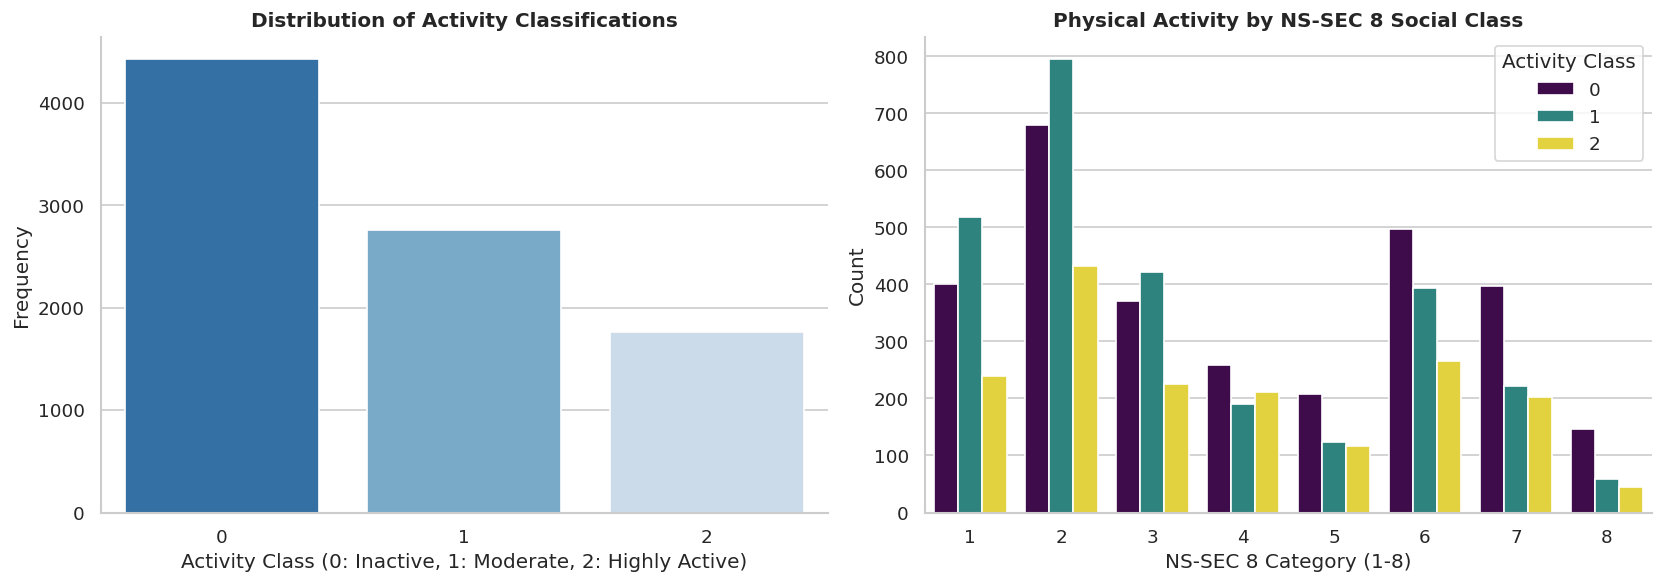

In [28]:
#  Exploratory Data Analysis - Behavioral Distributions
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Target Variable Distribution
sns.countplot(data=df_clean, x='activity_class', palette='Blues_r', ax=axes[0])
axes[0].set_title('Distribution of Activity Classifications', fontweight='bold')
axes[0].set_xlabel('Activity Class (0: Inactive, 1: Moderate, 2: Highly Active)')
axes[0].set_ylabel('Frequency')

# Plot 2: Social Status vs Activity Level
col_name = 'Social Status'

if col_name in df_clean.columns:


    valid_classes = [1, 2, 3, 4, 5, 6, 7, 8]
    plot_df = df_clean[df_clean[col_name].isin(valid_classes)].copy()

    plot_df[col_name] = plot_df[col_name].astype(int)

    if not plot_df.empty:
        sns.countplot(data=plot_df, x=col_name, hue='activity_class', palette='viridis', ax=axes[1])
        axes[1].set_title('Physical Activity by NS-SEC 8 Social Class', fontweight='bold')
        axes[1].set_xlabel('NS-SEC 8 Category (1-8)')
        axes[1].set_ylabel('Count')
        axes[1].legend(title='Activity Class', loc='upper right')
        axes[1].tick_params(axis='x', rotation=0) # Horizontal labels for clean reading
    else:
        axes[1].text(0.5, 0.5, "No valid 'Social Status' (1-8) found", ha='center', va='center')
else:
    axes[1].text(0.5, 0.5, "Column 'Social Status' not found in dataset", ha='center', va='center')

sns.despine()
plt.tight_layout()
plt.show()

In [42]:

# ------------------------------------------------------
# PLOT 1: ACTIVITY CLASS DISTRIBUTION
# ------------------------------------------------------
print("--- PLOT 1: ACTIVITY CLASS FREQUENCIES ---")
p1_counts = df_clean['activity_class'].value_counts().sort_index()
p1_pct = df_clean['activity_class'].value_counts(normalize=True).sort_index() * 100

p1_table = pd.DataFrame({
    'Raw Count': p1_counts,
    'Percentage (%)': p1_pct.round(2)
})
p1_table.index = ['0: Inactive', '1: Moderate', '2: Highly Active']
print(p1_table)
print("\n" + "="*55 + "\n")


# ------------------------------------------------------
# PLOT 2: NS-SEC 8 vs ACTIVITY LEVEL
# ------------------------------------------------------
if 'Social Status' in df_clean.columns:
    valid_classes = [1, 2, 3, 4, 5, 6, 7, 8]
    plot_df = df_clean[df_clean['Social Status'].isin(valid_classes)].copy()
    plot_df['Social Status'] = plot_df['Social Status'].astype(int)

    # 1. Raw counts (The exact height of the bars)
    print("--- PLOT 2: RAW BAR COUNTS (Contingency Table) ---")
    raw_crosstab = pd.crosstab(
        index=plot_df['Social Status'],
        columns=plot_df['activity_class'],
        margins=True,
        margins_name="TOTAL"
    )
    raw_crosstab.columns = ['0 (Inactive)', '1 (Moderate)', '2 (Active)', 'CLASS TOTAL']
    print(raw_crosstab)

    print("\n-------------------------------------------------------")
    # 2. Row-wise percentages
    print("--- PLOT 2: WITHIN-CLASS PERCENTAGES ---")
    print("(Reads as: 'Of all people in Social Class X, what % were active?')\n")

    pct_crosstab = pd.crosstab(
        index=plot_df['Social Status'],
        columns=plot_df['activity_class'],
        normalize='index'
    ) * 100
    pct_crosstab.columns = ['% Inactive', '% Moderate', '% Active']
    print(pct_crosstab.round(1))

else:
    print("Could not generate Plot 2 data: 'Social Status' not found.")

--- PLOT 1: ACTIVITY CLASS FREQUENCIES ---
                  Raw Count  Percentage (%)
0: Inactive            4425           49.47
1: Moderate            2758           30.84
2: Highly Active       1761           19.69


--- PLOT 2: RAW BAR COUNTS (Contingency Table) ---
               0 (Inactive)  1 (Moderate)  2 (Active)  CLASS TOTAL
Social Status                                                     
1                       401           518         240         1159
2                       680           795         432         1907
3                       371           421         226         1018
4                       259           190         212          661
5                       207           123         116          446
6                       497           393         266         1156
7                       397           222         203          822
8                       147            58          44          249
TOTAL                  2959          2720        1739     

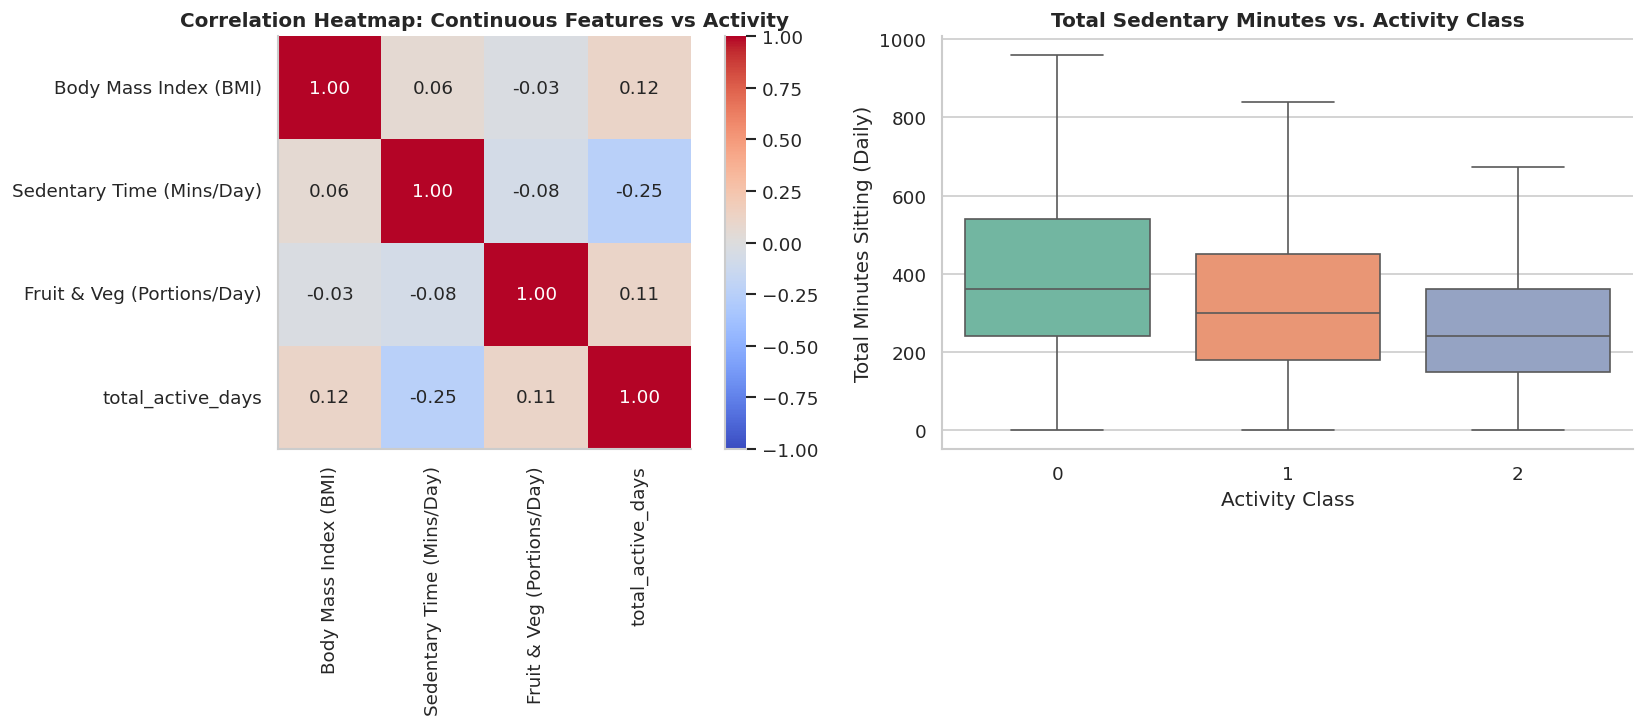

In [41]:
#  Exploratory Data Analysis - Continuous Variable Relationships
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
available_continuous = [col for col in continuous_features if col in df_clean.columns]

# Plot 1: Correlation Matrix of Continuous Variables
if available_continuous:
    plot_df = df_clean[available_continuous + ['total_active_days']].copy()
    corr_matrix = plot_df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[0], square=True)
    axes[0].set_title('Correlation Heatmap: Continuous Features vs Activity', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No continuous variables found', ha='center', va='center')

# Plot 2: Sedentary Time Distribution by Activity Class
if 'Sedentary Time (Mins/Day)' in df_clean.columns and df_clean['Sedentary Time (Mins/Day)'].notnull().any():
    sns.boxplot(data=df_clean, x='activity_class', y='Sedentary Time (Mins/Day)', palette='Set2', ax=axes[1], showfliers=False)
    axes[1].set_title('Total Sedentary Minutes vs. Activity Class', fontweight='bold')
    axes[1].set_xlabel('Activity Class')
    axes[1].set_ylabel('Total Minutes Sitting (Daily)')
else:
    axes[1].text(0.5, 0.5, "'Sedentary Time (Mins/Day)' data not found or empty", ha='center', va='center')

sns.despine()
plt.tight_layout()
plt.show()

In [31]:
#  Advanced Preprocessing & Pipeline Configuration
# ==============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

# 1. Partition the data (Used natively by LightGBM)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# 2. Build Scikit-Learn Preprocessor (Required for RF and MLP convergence)
avail_cont = [c for c in continuous_features if c in X_train.columns]
avail_cat = [c for c in categorical_features if c in X_train.columns]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, avail_cont),
        ('cat', categorical_transformer, avail_cat)
    ])

# 3. Pre-transform data to accelerate hyperparameter tuning for RF and MLP
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data partitioning complete. Preprocessing pipelines established for all architectures.")

Data partitioning complete. Preprocessing pipelines established for all architectures.


In [32]:
#  Model 1 Optimization: LightGBM (Gradient Boosting)
# ==============================================================================
print("Initiating Grid Search for LightGBM...")

lgbm_base = LGBMClassifier(class_weight='balanced', n_jobs=-1, verbose=-1)

# Define Hyperparameter Space
lgbm_param_grid = {
    'n_estimators': [100, 250],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05]
}

lgbm_grid = GridSearchCV(lgbm_base, lgbm_param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit utilizing native categorical handling
lgbm_grid.fit(X_train, y_train, categorical_feature=available_cat_features)

best_lgbm = lgbm_grid.best_estimator_
print(f"Optimal LightGBM Parameters: {lgbm_grid.best_params_}")
print(f"Cross-Validation Accuracy: {lgbm_grid.best_score_:.4f}")

Initiating Grid Search for LightGBM...
Optimal LightGBM Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Cross-Validation Accuracy: 0.6526


In [33]:
#  Model 2 Optimization: Random Forest
# ==============================================================================
print("Initiating Grid Search for Random Forest...")

rf_base = RandomForestClassifier(class_weight='balanced', n_jobs=-1)

# Define Hyperparameter Space
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit utilizing the mathematically scaled dataset
rf_grid.fit(X_train_processed, y_train)

best_rf = rf_grid.best_estimator_
print(f"Optimal Random Forest Parameters: {rf_grid.best_params_}")
print(f"Cross-Validation Accuracy: {rf_grid.best_score_:.4f}")

Initiating Grid Search for Random Forest...
Optimal Random Forest Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Cross-Validation Accuracy: 0.6458


In [34]:
#  Model 3 Optimization: Artificial Neural Network (MLP)
# ==============================================================================
print("Initiating Neural Network Training Sequence...")

# Configuring an advanced MLP with early stopping to prevent over-fitting
best_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Deep architecture
    activation='relu',             # Non-linear activation
    solver='adam',                 # Adaptive momentum optimizer
    alpha=0.001,                   # L2 penalty (regularization)
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=False,
    tol=1e-6,
    validation_fraction=0.1,
    n_iter_no_change=50
)

best_mlp.fit(X_train_processed, y_train)

print(f"Neural Network convergence achieved in {best_mlp.n_iter_} epochs.")

Initiating Neural Network Training Sequence...
Neural Network convergence achieved in 739 epochs.


Training MLP for 100 epochs. Tracking validation loss...
Training Complete! Generating plot...


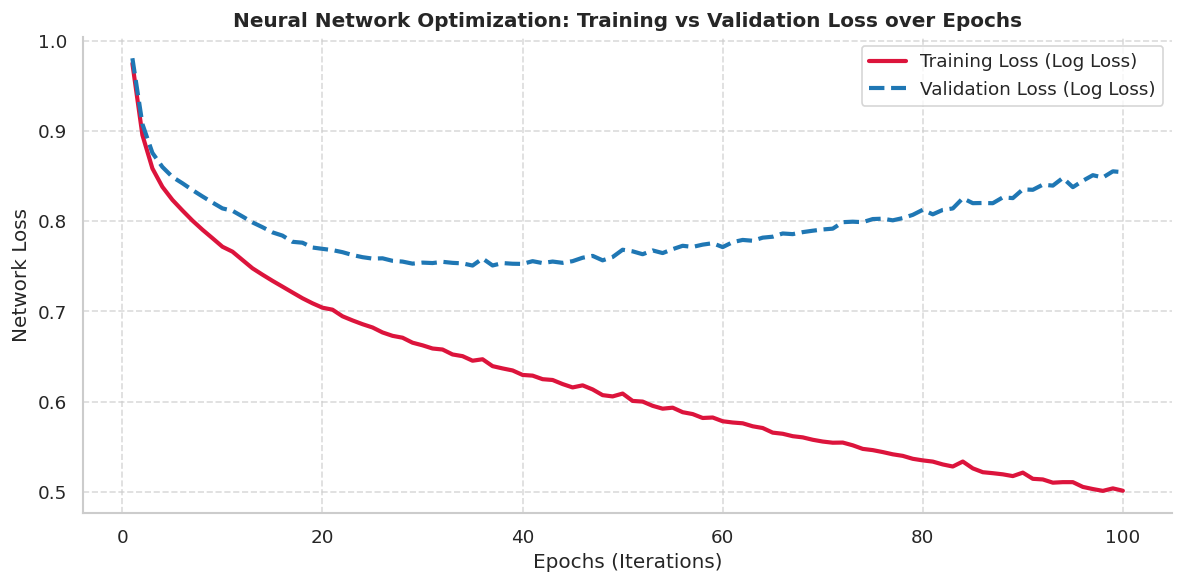

In [35]:

from sklearn.metrics import log_loss

X_data = X_train_processed

# Split a 20% validation set specifically for tracking loss during training
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_data, y_train, test_size=0.2, stratify=y_train
)

# Initialize the MLPClassifier with strongly regularized parameters to force generalization
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Reduced complexity so it can't just memorize the data
    alpha=0.1,                     # Increased L2 penalty to force the model to learn general patterns
    learning_rate_init=0.001,
    solver='adam',

)

# Lists to store the loss values
train_loss = []
val_loss = []
classes = np.unique(y_train_split)

# Train the model epoch by epoch
epochs = 100
print(f"Training MLP for {epochs} epochs. Tracking validation loss...")

for epoch in range(epochs):
    # partial_fit trains the model for exactly one step at a time
    mlp_model.partial_fit(X_train_split, y_train_split, classes=classes)

    # Predict probabilities to calculate the log loss
    train_pred_probs = mlp_model.predict_proba(X_train_split)
    val_pred_probs = mlp_model.predict_proba(X_val_split)

    # Store the loss for this specific epoch
    train_loss.append(log_loss(y_train_split, train_pred_probs))
    val_loss.append(log_loss(y_val_split, val_pred_probs))

print("Training Complete! Generating plot...")

plt.figure(figsize=(10, 5))

# Plotting Training Loss
plt.plot(range(1, epochs + 1), train_loss, label='Training Loss (Log Loss)', color='crimson', linewidth=2.5)

# Plotting Validation Loss
plt.plot(range(1, epochs + 1), val_loss, label='Validation Loss (Log Loss)', color='#1f77b4', linewidth=2.5, linestyle='--')

# Adding labels, title, and grid
plt.title('Neural Network Optimization: Training vs Validation Loss over Epochs', fontweight='bold')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Network Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# seaborn styling
sns.despine()
plt.tight_layout()
plt.show()

--- Final Holdout Test Performance Metrics ---


,Accuracy,Precision,Recall,F1-Score
Architecture,,,,
LightGBM,0.6506,0.6114,0.6142,0.6073
Random Forest,0.6283,0.5658,0.5613,0.5601
Neural Network,0.5640,0.4954,0.4955,0.4952


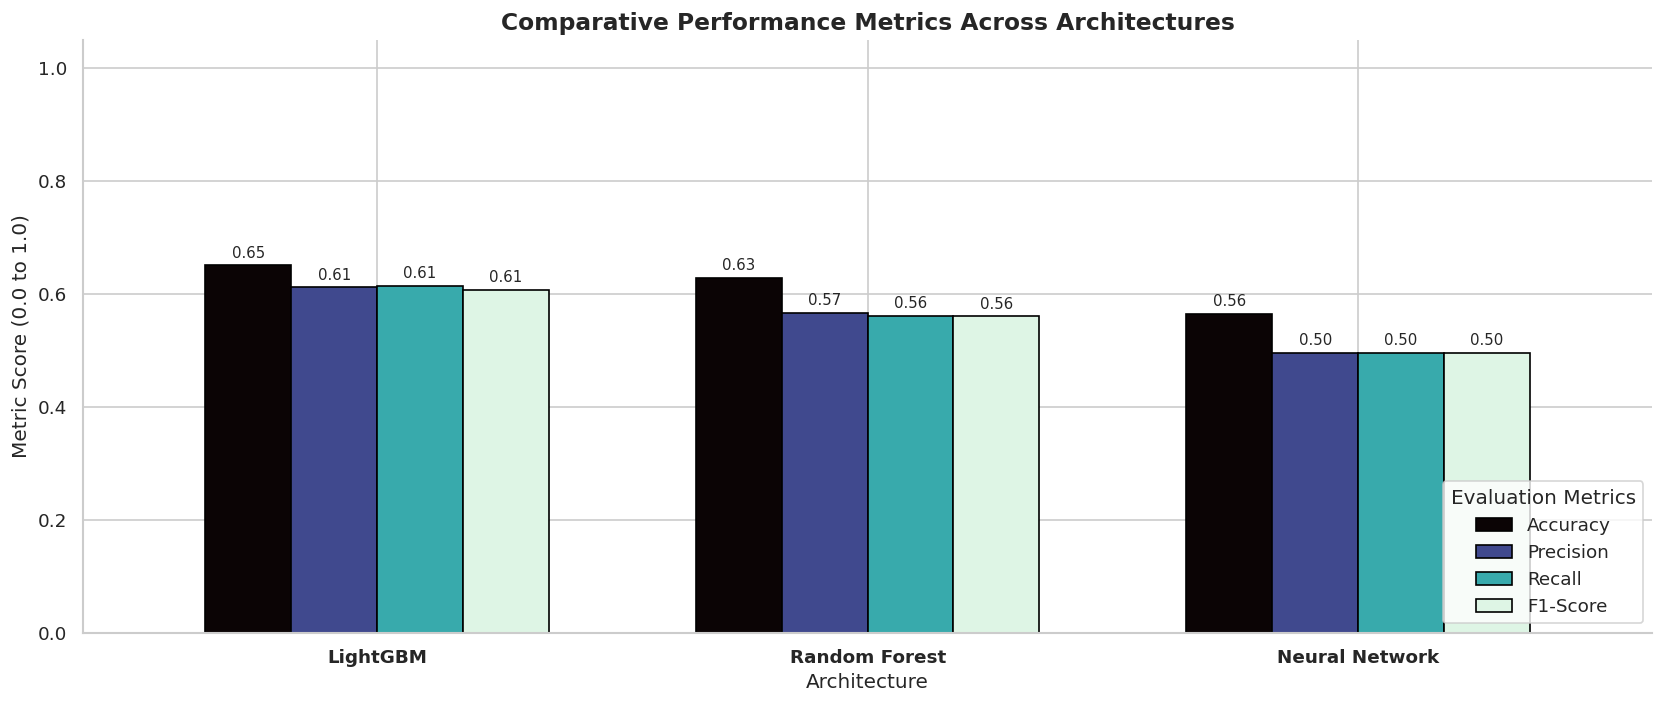

In [36]:
#  Comparative Architectural Study & Evaluation Metrics
# ==============================================================================
from sklearn.metrics import precision_recall_fscore_support

# Map the tuned models to their correct test datasets
models_dict = {
    'LightGBM': (best_lgbm, X_test),               # Uses native data
    'Random Forest': (best_rf, X_test_processed),  # Uses scaled data
    'Neural Network': (best_mlp, X_test_processed) # Uses scaled data
}

results = []
for name, (model, test_data) in models_dict.items():
    y_pred = model.predict(test_data)
    acc = accuracy_score(y_test, y_pred)
    # Calculate Macro-averaged metrics for imbalanced multi-class
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        'Architecture': name, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1-Score': f1
    })

results_df = pd.DataFrame(results).set_index('Architecture')

# Display Data Table
print("--- Final Holdout Test Performance Metrics ---")
display(results_df.round(4))

# Plot Multi-Metric Comparison
results_df.plot(kind='bar', figsize=(14, 6), colormap='mako', edgecolor='black', width=0.7)
plt.title('Comparative Performance Metrics Across Architectures', fontweight='bold', fontsize=14)
plt.ylabel('Metric Score (0.0 to 1.0)')
plt.ylim(0, 1.05)
plt.legend(loc='lower right', title='Evaluation Metrics')
plt.xticks(rotation=0, fontweight='bold')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3, fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

Making predictions...
Drawing Confusion Matrix...


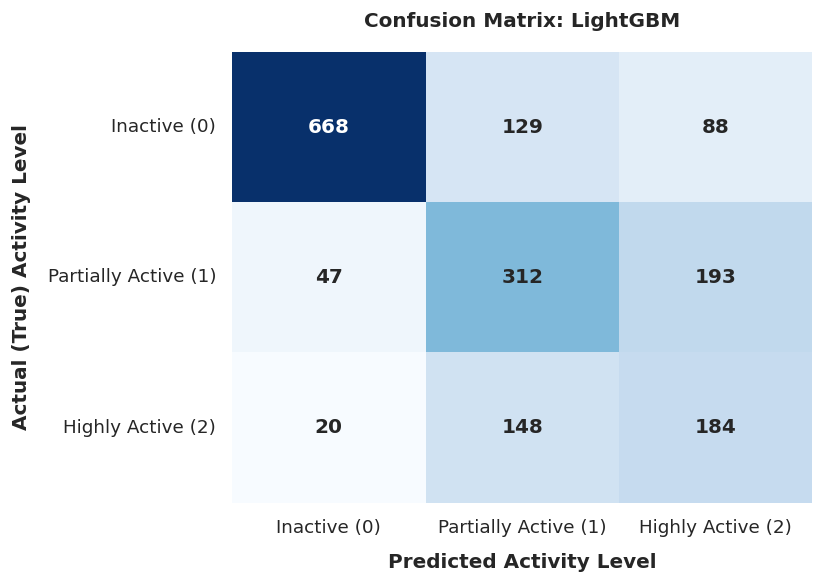

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

my_model = best_lgbm
my_X_test = X_test
my_y_test = y_test

print("Making predictions...")

# 1. Ask the model to make predictions on the test data
y_pred = my_model.predict(my_X_test)

# 2. Calculate the raw confusion matrix
cm = confusion_matrix(my_y_test, y_pred)

print("Drawing Confusion Matrix...")

# 3. Create a beautiful heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inactive (0)', 'Partially Active (1)', 'Highly Active (2)'],
            yticklabels=['Inactive (0)', 'Partially Active (1)', 'Highly Active (2)'],
            cbar=False, annot_kws={"size": 12, "weight": "bold"})

# 4. Add formatting and labels
plt.title('Confusion Matrix: LightGBM', fontweight='bold', pad=15)
plt.xlabel('Predicted Activity Level', fontweight='bold', labelpad=10)
plt.ylabel('Actual (True) Activity Level', fontweight='bold', labelpad=10)

# 5. Display the plot
plt.tight_layout()
plt.show()


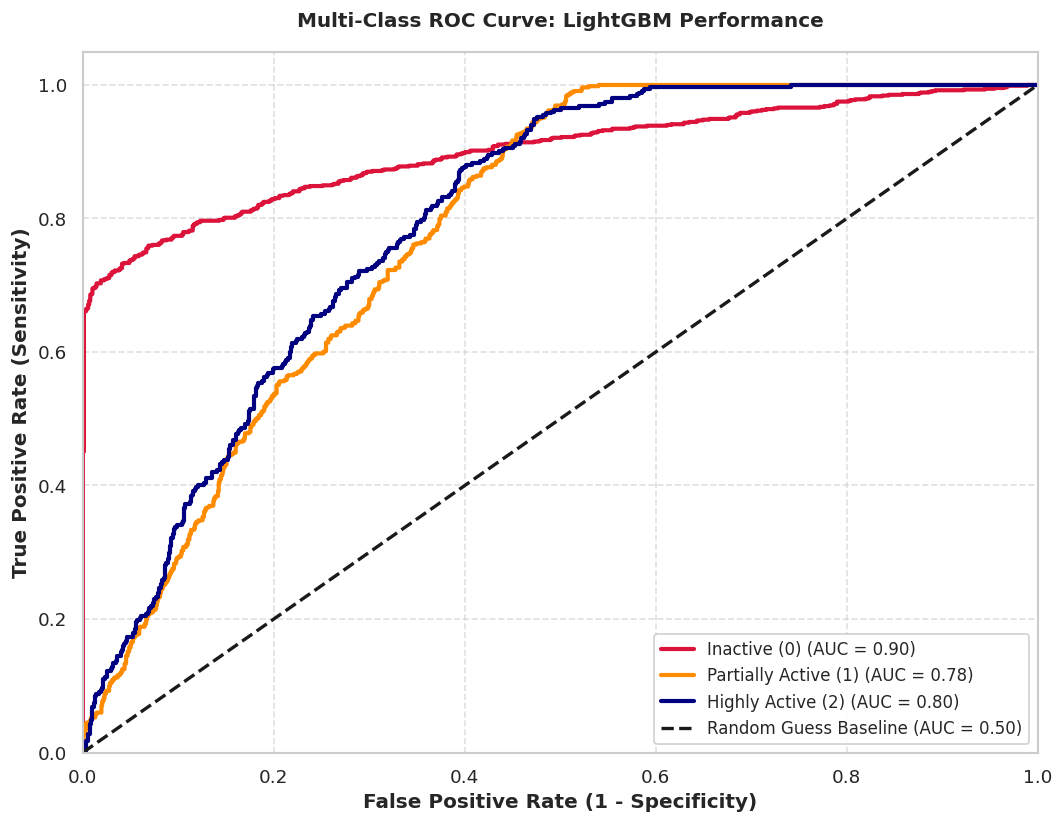

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ==============================================================================
# MULTI-CLASS ROC-AUC FOR LightGBM
# ==============================================================================
# 1. Binarize the true labels for multi-class ROC math
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 2. Predict PROBABILITIES (not just strict classes) using your winning LightGBM
y_score = best_lgbm.predict_proba(X_test)

# 3. Calculate ROC curve and AUC for each individual class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the curves professionally
plt.figure(figsize=(9, 7))
colors = ['crimson', 'darkorange', 'navy']
class_names = ['Inactive (0)', 'Partially Active (1)', 'Highly Active (2)']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Add the 'blind guess' baseline diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess Baseline (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
plt.title('Multi-Class ROC Curve: LightGBM Performance', fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

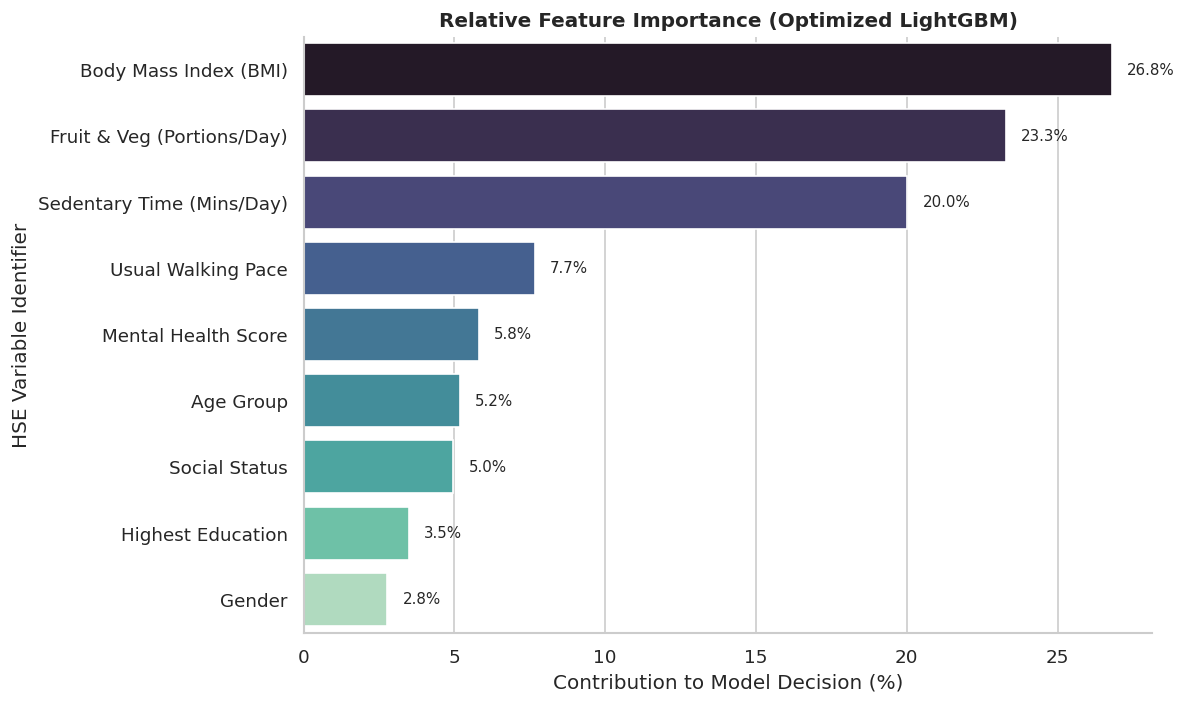

In [39]:
#  Model Interpretability - Feature Importance
# ==============================================================================
# Extract normalized feature importances from the hyper-tuned LightGBM
importances = best_lgbm.feature_importances_
importance_pct = (importances / importances.sum()) * 100

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Pct': importance_pct
}).sort_values(by='Importance_Pct', ascending=False)

# Visualize top predictors
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance_Pct', y='Feature', palette='mako')
plt.title('Relative Feature Importance (Optimized LightGBM)', fontweight='bold')
plt.xlabel('Contribution to Model Decision (%)')
plt.ylabel('HSE Variable Identifier')

# Annotate bars
for index, value in enumerate(feature_importance_df['Importance_Pct']):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

# ==============================================================================
# INTERACTIVE PREDICTIVE TOOL (MODEL INFERENCE SIMULATOR)
# ==============================================================================
print("Loading Interactive Patient Simulator...")

template_patient = X_test.iloc[[0]].copy()

def predict_activity_level(bmi, sedentary_time):
    """
    This function takes the slider inputs, updates the template patient,
    and runs it through your winning LightGBM model.
    """
    hypothetical_patient = template_patient.copy()
    hypothetical_patient['Body Mass Index (BMI)'] = bmi
    hypothetical_patient['Sedentary Time (Mins/Day)'] = sedentary_time

    # Run the LightGBM prediction
    prediction = best_lgbm.predict(hypothetical_patient)[0]
    probabilities = best_lgbm.predict_proba(hypothetical_patient)[0]

    # Map the numerical prediction back to readable text
    class_names = {0.0: "Inactive", 1.0: "Partially Active", 2.0: "Highly Active"}
    predicted_text = class_names.get(prediction, "Unknown")
    confidence = probabilities[int(prediction)] * 100

    # Determine a color for the output box based on the prediction
    colors = {"Inactive": "#ff4c4c", "Partially Active": "#ffae42", "Highly Active": "#32cd32"}
    bg_color = colors.get(predicted_text, "#ffffff")

    # Display a beautiful HTML result box
    html_output = f"""
    <div style="border: 2px solid #ccc; padding: 15px; border-radius: 10px; background-color: #f9f9f9; width: 400px; text-align: center;">
        <h3 style="margin-top: 0;">AI Diagnosis</h3>
        <p style="font-size: 16px;">Based on a BMI of <b>{bmi}</b> and <b>{sedentary_time}</b> sedentary minutes/day:</p>
        <div style="background-color: {bg_color}; color: white; padding: 10px; border-radius: 5px; font-size: 20px; font-weight: bold; margin: 10px 0;">
            {predicted_text}
        </div>
        <p style="margin-bottom: 0;">AI Confidence: <b>{confidence:.1f}%</b></p>
    </div>
    """
    display(HTML(html_output))

# 2. Create the interactive sliders

style = {'description_width': 'initial'}

bmi_slider = widgets.FloatSlider(
    value=25.0, min=15.0, max=45.0, step=0.5,
    description='Body Mass Index (BMI):',
    style=style, layout=widgets.Layout(width='400px')
)

sedentary_slider = widgets.IntSlider(
    value=300, min=0, max=900, step=15,
    description='Sedentary Time (Mins/Day):',
    style=style, layout=widgets.Layout(width='400px')
)

# 3. Launch the interactive tool
print("\n--- HYPOTHETICAL PATIENT SIMULATOR ---")
print("Move the sliders below to see the AI predict the activity level in real-time!\n")
widgets.interact(predict_activity_level, bmi=bmi_slider, sedentary_time=sedentary_slider);